# MOBILENETV2



# Giới thiệu về Kiến trúc MobileNetV2

## 1. Cấu trúc và Số lượng Lớp của MobileNetV2
MobileNetV2 là một mạng nơ-ron sâu (Deep Neural Network) bao gồm **53 lớp**. Tuy nhiên, điểm làm nên tên tuổi của nó không nằm ở số lượng, mà nằm ở "chất lượng" của các lớp này.

Thay vì dùng bộ lọc hình ảnh nặng nề truyền thống, MobileNetV2 sử dụng một kỹ thuật tối ưu cốt lõi gọi là **Depthwise Separable Convolutions (Tích chập tách biệt theo chiều sâu)**.

### 💡 Cách hiểu đơn giản (Ví dụ Tiệm ăn):
> Giống như trong một nhà hàng, thay vì một đầu bếp phải tự làm mọi việc từ nhặt rau, thái thịt đến xào nấu (quy trình rất chậm), MobileNetV2 chia nhỏ công việc ra thành một dây chuyền:
> * **Lớp thứ nhất (Depthwise):** Chỉ chuyên lọc từng mảng màu sắc, đường nét riêng biệt trên từng kênh màu.
> * **Lớp thứ hai (Pointwise):** Chỉ chuyên trộn các mảng màu, thông tin đó lại với nhau để tìm ra ý nghĩa tổng thể.
>
> Việc chia nhỏ này giúp mô hình giảm thiểu tối đa số lượng phép tính, giúp mạng chạy **cực kỳ nhanh và nhẹ**, phù hợp hoàn hảo cho cả các thiết bị điện thoại di động và thiết bị nhúng.


## 2. Cách các Lớp Tương tác với Nhau (Dây chuyền Nhận thức)
53 lớp của MobileNetV2 không hoạt động độc lập mà truyền dữ liệu nối tiếp nhau tạo thành một chuỗi cung ứng thông tin liên tục. Từ lúc bức ảnh (ví dụ: ảnh một chiếc áo) đi vào cho đến khi có kết quả phân loại cuối cùng, dữ liệu sẽ lần lượt đi qua **3 giai đoạn tương tác** chính:

### 🔍 Giai đoạn 1: Các lớp đầu tiên (Lớp Thấp) – *Vai trò: "Kính lúp"*
* **Chức năng:** Tìm kiếm và phát hiện các đặc trưng hình học cơ bản nhất.
* **Chi tiết nhận diện:** Các đường thẳng, mép vải, góc nhọn, sự thay đổi giữa vùng sáng và vùng tối. Ở giai đoạn này, mạng chưa hiểu "chiếc áo" là gì, nó chỉ thấy các nét vẽ rời rạc.

### 🧩 Giai đoạn 2: Các lớp ở giữa (Lớp Trung) – *Vai trò: "Bộ ghép hình"*
* **Chức năng:** Nhận các đường nét cơ bản từ các lớp thấp truyền sang và tiến hành tổ hợp, kết nối chúng lại thành các chi tiết có cấu trúc phức tạp hơn.
* **Chi tiết nhận diện:** Các họa tiết sọc ngang/sọc dọc, các nếp gấp vải, hình dáng cổ áo, ống quần, túi áo hoặc cúc áo.

### 🎓 Giai đoạn 3: Các lớp cuối cùng (Lớp Cao) – *Vai trò: "Người tổng hợp"*
* **Chức năng:** Quan sát toàn bộ các chi tiết cấu thành đã được lắp ghép ở lớp trung, đánh giá mối quan hệ logic giữa chúng để đưa ra kết luận và định danh đối tượng.
* **Chi tiết nhận diện:** Tổng hợp thông tin (Ví dụ: tổng hợp các đặc trưng gồm *có cổ áo + có tay ngắn + chất liệu vải thun*) để đưa ra phán quyết cuối cùng với xác suất cao nhất: **"Đây là một chiếc áo thun"**.


## 3. Sơ đồ tượng trưng: Frozen (Đóng băng) và Fine-Tuned (Học lại)
Trong học chuyển giao (Transfer Learning), bạn không bắt mô hình học lại từ đầu. Bạn giữ lại sự thông minh vốn có của nó và chỉ dạy lại phần cuối cùng. Dưới đây là sơ đồ tượng trưng cho bộ não của MobileNetV2 trong bài toán của bạn:

```text
               [ ĐẦU VÀO: Bức ảnh cái quần / cái áo ]
                              |
                              v
====================================================================
🧊 PHẦN 1: KHỐI TRÍCH XUẤT ĐẶC TRƯNG - TRẠNG THÁI: FROZEN (ĐÓNG BĂNG) 🧊
====================================================================
* Bao gồm: Khoảng 52 lớp đầu tiên của mô hình.
* Chức năng: Đóng vai trò làm "Đôi mắt".
* Tại sao lại Frozen? Google đã dùng siêu máy tính và hàng triệu bức 
  ảnh (ImageNet) để dạy khối này cách nhìn nhận thế giới. Nó đã quá 
  giỏi trong việc phân biệt các đường nét, góc cạnh, chất liệu vải. 
  Bạn "đóng băng" (khóa) nó lại để tiết kiệm thời gian huấn luyện. 
  Trọng số (Weights) ở đây hoàn toàn nằm im, không bị thay đổi.
                              |
                              v
        (Truyền xuống các thông tin: "Có đường thẳng, có nếp gấp vải...")
                              |
                              v
====================================================================
🔥 PHẦN 2: KHỐI PHÂN LOẠI - TRẠNG THÁI: FINE-TUNED (HUẤN LUYỆN LẠI) 🔥
====================================================================
* Bao gồm: 1 lớp Linear duy nhất ở cuối cùng (Lớp số 53).
* Chức năng: Đóng vai trò làm "Người ra quyết định".
* Tại sao lại Fine-Tuned? Lớp cuối cùng nguyên bản của Google được 
  thiết kế để đoán 1000 con vật/đồ vật khác nhau. Bạn đập bỏ lớp đó đi, 
  thay bằng một lớp mới tinh chỉ đoán 10 loại quần áo của bạn. Trong lúc 
  máy tính chạy, chỉ có trọng số (Weights) ở khu vực này liên tục 
  thay đổi và tự sửa sai để học cách khớp các đặc trưng ở trên với kết 
  quả là 10 nhãn (Áo thun, Quần dài, Giày thể thao...).
====================================================================
                              |
                              v
       [ ĐẦU RA: Kết quả dự đoán % cho 10 loại quần áo cụ thể ]
```


## Áp dụng mô hình MobileNet về bài toán phân loại quần áo

### BƯỚC 1: CÀI ĐẶT THƯ VIỆN VÀ TẢI DATASET



**Mục đích:** Chuẩn bị công cụ (thư viện) và "sơ chế" hình ảnh trước khi đưa cho AI học.

### Những dòng code quan trọng nhất và ý nghĩa:
1. **Chọn thiết bị:**
   ```python
   device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
   ```
   * **Đời thường:** Máy tính kiểm tra xem có Card đồ họa rời (GPU - "Cuda") không. Nếu có, nó sẽ dùng GPU (chạy cực nhanh). Nếu không, nó dùng CPU (chạy chậm).

2. **Tiền xử lý ảnh:**
   ```python
   transforms.Resize((224, 224)),
   transforms.Grayscale(num_output_channels=3),
   ```
   * **Đời thường:** Bức ảnh quần áo ban đầu bé xíu (28x28) và là ảnh trắng đen. Nhưng MobileNetV2 lại là người Tây, chỉ quen nhìn ảnh màu to (224x224). Thế nên ta phải dùng lệnh `Resize` để phóng to ảnh, và `Grayscale(3)` để nhân bản màu xám thành 3 lớp, "lừa" AI rằng đây là ảnh màu.

3. **Chia mẻ dữ liệu (DataLoader):**
   ```python
   train_loader = DataLoader(Subset(full_train_dataset, train_indices), batch_size=64, shuffle=True)
   ```
   * **Đời thường:** Bạn có 60.000 bức ảnh. Bạn không thể nhồi nhét tất cả vào não AI cùng một lúc (nó sẽ bị quá tải bộ nhớ RAM). `batch_size=64` nghĩa là bạn chia ra, mỗi lần chỉ cho AI xem đúng 64 bức ảnh, học xong lại lấy 64 bức tiếp theo. `shuffle=True` là xáo trộn ảnh lên để AI không "học vẹt" thứ tự.
   * **batch_size:** là số lượng mẫu dữ liệu (ví dụ: số bức ảnh) được gộp chung lại để đưa vào mô hình tính toán trong một lượt, trước khi mô hình tự động cập nhật lại trọng số (rút kinh nghiệm sửa sai).


In [1]:
# CÀI ĐẶT THƯ VIỆN
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Đang sử dụng device:", device)

# TIỀN XỬ LÝ RIÊNG CHO MOBILENETV2
transform_mobilenet = transforms.Compose([
    transforms.Resize((224, 224)), # Phóng to ảnh để phù hợp với input của MobileNetV2
    transforms.Grayscale(num_output_channels=3), # Nhân bản 1 kênh xám thành 3 kênh RGB ảo
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Chuẩn hóa theo ImageNet
])

# Tải lại Dataset với Transform mới
full_train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform_mobilenet)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform_mobilenet)

# Chia Train/Val 
train_indices, val_indices = train_test_split(
    list(range(len(full_train_dataset))), 
    test_size=0.2, 
    stratify=full_train_dataset.targets
)

train_loader = DataLoader(Subset(full_train_dataset, train_indices), batch_size=64, shuffle=True)
val_loader = DataLoader(Subset(full_train_dataset, val_indices), batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Đã tải xong dữ liệu cho MobileNetV2!")

Đang sử dụng device: cpu
Đã tải xong dữ liệu cho MobileNetV2!


### BƯỚC 2: KHỞI TẠO MÔ HÌNH MOBILENETV2

**Mục đích:** Mượn một mô hình đã rất thông minh (Google tạo ra sẵn) và chỉnh sửa lại để nó phục vụ riêng cho mình.

### Các bước cụ thể:
1. **Pre-trained Model:**
   ```python
   model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
   ```
   * **Đời thường:** Bạn tải về MobileNetV2. Chữ `DEFAULT` nghĩa là bạn tải luôn cả "kiến thức" mà nó đã học từ hàng triệu bức ảnh trên mạng. Nó đã biết cách phân biệt đường nét, góc cạnh, chất liệu.

2. **Đóng băng kiến thức cũ:**
   ```python
   for param in model.parameters():
       param.requires_grad = False
   ```
   *  Máy tính sẽ **khóa** các lớp học nhận diện nét vẽ lại (không tính toán cập nhật nữa) để chạy cho nhanh.

3. **Thay thế lớp đầu ra:**
   ```python
   in_features = model.classifier[1].in_features
   model.classifier[1] = nn.Linear(in_features, 10)
   ```
   * **Đời thường:**. Bạn gỡ bỏ cái trí nhớ 1000 món đó đi, lắp vào một bộ nhớ mới tinh chỉ có  10 loại quần áo của tập FashionMNIST. Bây giờ, ta chỉ cần huấn luyện đúng cái lớp cuối cùng này thôi.



In [2]:
# 1. Tải mô hình đã Pre-train
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# 2. Đóng băng các lớp Tích chập (Chỉ huấn luyện lại lớp phân loại cuối cùng cho nhanh)
for param in model.parameters():
    param.requires_grad = False

# 3. Thay "cái đầu" (Classifier) của mô hình
# MobileNetV2 mặc định đoán 1000 lớp, ta sửa lại thành 10 lớp quần áo
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 10)

model = model.to(device)

# Thiết lập hàm loss và thuật toán tối ưu (chỉ tối ưu classifier)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

print("Đã khởi tạo xong MobileNetV2!")

Đã khởi tạo xong MobileNetV2!


### BƯỚC 3: VÒNG LẬP HUẤN LUYỆN (QUÁ TRÌNH HỌC TẬP)

**Mục đích:** Cho AI xem ảnh, bắt nó đoán, chấm điểm và ép nó sửa sai.

### Cơ chế hoạt động:
* `EPOCHS = 5`: Quá trình học lặp lại 5 chu kỳ. Giống như học sinh ôn đi ôn lại sách giáo khoa 5 lần.

**Quy trình chuẩn trong vòng `train_loader` (4 bước thần thánh):**
1. **Làm bài tập (`outputs = model(inputs)`):** AI nhìn 64 bức ảnh và đưa ra dự đoán (ví dụ: đoán 90% là cái áo sơ mi).
2. **Chấm điểm (`loss = criterion(outputs, labels)`):** Thầy giáo (Hàm Loss) so sánh câu trả lời của AI với đáp án thật. Nếu sai nhiều, điểm Loss sẽ rất cao.
3. **Rút kinh nghiệm (`loss.backward()`):** Máy tính phân tích xem tại sao lại sai. Lỗi do đâu? (Tính đạo hàm).
4. **Sửa sai (`optimizer.step()`):** Thuật toán tự động điều chỉnh lại các con số trong bộ não AI để lần sau nó đoán chuẩn hơn.

*Phần nửa dưới của ô code (`val_loader`) là quá trình **Thi thử**: AI làm bài kiểm tra trên tập dữ liệu nó chưa từng học để xem nó có thực sự thông minh lên không.*


In [3]:
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    model.eval()
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    print(f"Epoch {epoch+1}/{EPOCHS} - "
          f"Train Loss: {running_loss/len(train_loader):.4f}, Train Acc: {100 * correct / total:.2f}% - "
          f"Val Loss: {val_loss/len(val_loader):.4f}, Val Acc: {100 * val_correct / val_total:.2f}%")

Epoch 1/5 - Train Loss: 0.7841, Train Acc: 75.78% - Val Loss: 0.5448, Val Acc: 81.49%
Epoch 2/5 - Train Loss: 0.5399, Train Acc: 81.47% - Val Loss: 0.4898, Val Acc: 83.15%
Epoch 3/5 - Train Loss: 0.5022, Train Acc: 82.58% - Val Loss: 0.4665, Val Acc: 83.74%
Epoch 4/5 - Train Loss: 0.4827, Train Acc: 83.02% - Val Loss: 0.4515, Val Acc: 84.10%
Epoch 5/5 - Train Loss: 0.4713, Train Acc: 83.31% - Val Loss: 0.4416, Val Acc: 84.27%


#### Trong quá trình AI học tập:
  * **Epoch:** Một Epoch trôi qua nghĩa là AI đã xem qua toàn bộ bộ ảnh huấn luyện 1 lần. 5 Epochs là xem lại 5 lần.
  * **Loss (Train Loss/Val Loss):** "Điểm phạt" hay mức độ sai sót. Điểm này càng thấp chứng tỏ AI đoán càng sát với thực tế. Train Loss là điểm phạt khi làm bài tập ở nhà, Val Loss là điểm phạt khi thi thử.
  * **Accuracy (Train Acc/Val Acc):** "Điểm số" tính bằng phần trăm. 84.27% nghĩa là cứ 100 ảnh thi thử thì nó đoán đúng khoảng 84 ảnh.


### BƯỚC 4: KIỂM THỬ VÀ ĐÁNH GIÁ MÔ HÌNH (EVALUATION)

**Mục đích:** Sau khi tốt nghiệp (train xong), AI phải đi thi thật trên tập ảnh Test (Những ảnh bị giấu kín từ đầu).

1. **Khóa chế độ học (`with torch.no_grad():`)**
   * **Đời thường:** Đã đi thi thì cấm mở sách! Lệnh này tắt tính năng "Rút kinh nghiệm và sửa sai" của AI. Lúc này nó chỉ có nhiệm vụ duy nhất là đoán dựa trên những gì đã học.

2. **In bảng điểm (Classification Report):**
   * Báo cáo này sẽ chỉ ra:
     * **Precision:** Trong số 100 cái áo AI nhận diện, có bao nhiêu cái thực sự là áo?
     * **Recall:** Trong 100 cái áo có ngoài đời thực, AI phát hiện ra được bao nhiêu cái?
     * **F1 Score:** Điểm tổng hợp giữa Precision và Recall -> AI vừa đoán chính xác, vừa không bỏ sót
     * **Support:** Số lượng ảnh thực tế của từng món đồ mang đi thi (ở đây là 1000 ảnh cho mỗi loại).



3. **Vẽ biểu đồ nhầm lẫn (Confusion Matrix):**
   * **Đời thường:** Vẽ ra một cái bảng vuông. 
   * Nhìn vào đường chéo từ góc trên bên trái xuống góc dưới bên phải: Những con số ở đây là số lần đoán **ĐÚNG**.
   * Những con số nằm lọt ra ngoài đường chéo là số lần đoán **SAI**. Bạn nhìn vào đó sẽ biết ngay AI của mình có bị nhầm "Áo Sơ mi" với "Áo Thun" không. 

---


--- KẾT QUẢ CỦA MOBILENETV2 TRÊN TẬP TEST ---
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.80      0.80      1000
     Trouser       0.98      0.94      0.96      1000
    Pullover       0.77      0.80      0.79      1000
       Dress       0.78      0.84      0.81      1000
        Coat       0.77      0.72      0.74      1000
      Sandal       0.97      0.92      0.94      1000
       Shirt       0.60      0.58      0.59      1000
     Sneaker       0.90      0.96      0.93      1000
         Bag       0.94      0.97      0.95      1000
  Ankle boot       0.96      0.94      0.95      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



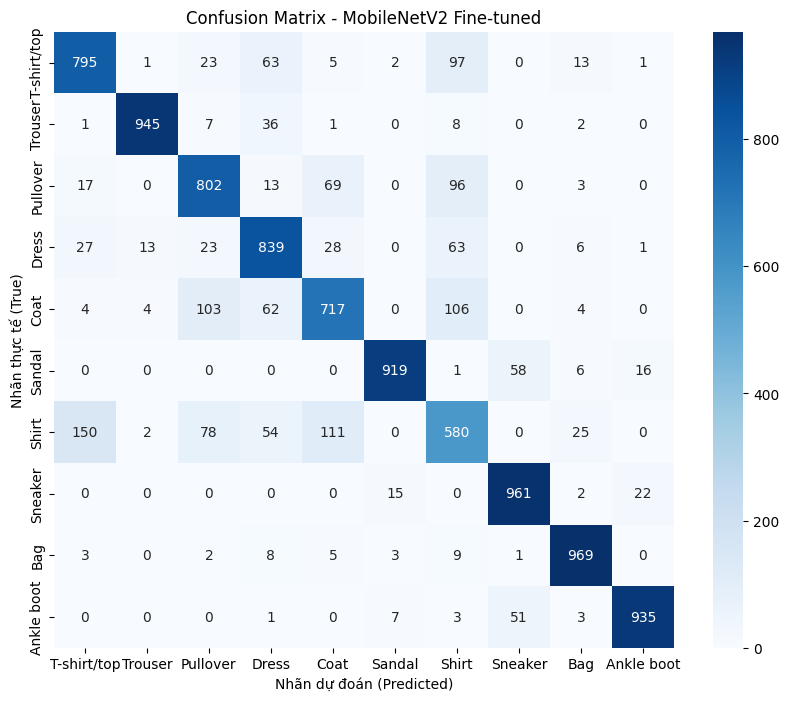

In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# In báo cáo phân loại
print("--- KẾT QUẢ CỦA MOBILENETV2 TRÊN TẬP TEST ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Nhãn dự đoán (Predicted)')
plt.ylabel('Nhãn thực tế (True)')
plt.title('Confusion Matrix - MobileNetV2 Fine-tuned')
plt.show()

#### Nhận xét chi tiết về "Học lực" của mô hình MobileNetV2

##### 1. Quá trình học tập rất ổn định và khỏe mạnh (Training Progress)
Mô hình của bạn đang có một lộ trình học tập rất tốt và đi đúng hướng.

* **Sự tiến bộ qua từng vòng (Epoch):** Qua mỗi Epoch, *Train Loss* giảm dần (từ 0.78 xuống 0.47) và *Train Acc* tăng lên một cách đều đặn (từ 75% lên 83%). Điều này chứng tỏ AI thực sự đang tiếp thu kiến thức, biết tự sửa sai qua mỗi vòng lặp chứ không bị mất phương hướng hay bị "lú".
* **Khả năng tổng quát hóa tốt:** Điều quan trọng nhất là *Val Acc* (kết quả trên tập kiểm thử/thi thử) liên tục bám đuổi sát sao và thậm chí có những thời điểm cao hơn *Train Acc*. Đây là dấu hiệu vàng cho thấy AI của bạn đang hiểu được bản chất đặc trưng của trang phục, hoàn toàn không bị mắc căn bệnh **"học vẹt" (Overfitting)** — hiện tượng chỉ học thuộc lòng dữ liệu huấn luyện nhưng gặp ảnh lạ là đoán sai.

---

##### 2. Kết quả "Test" tổng kết khá ấn tượng (Evaluation Metrics)
Độ chính xác tổng thể (**Accuracy**) của mô hình đạt **85%**. Đối với một kiến trúc mạng tinh gọn, tối ưu cho thiết bị di động như MobileNetV2 và chỉ mới trải qua vỏn vẹn **5 vòng huấn luyện (Epochs)**, đây là một con số cực kỳ đáng khích lệ!

Khi phân tích sâu vào từng danh mục (Class), ta thấy sự phân hóa rõ rệt trong "năng lực" của AI:

* **Nhóm chuyên gia (Giày và Túi):** Các danh mục bao gồm **Trouser** (Quần), **Sneaker** (Giày thể thao), **Bag** (Túi xách), và **Ankle boot** (Bốt) đều đạt chỉ số **F1-score cực kỳ cao (trên 0.93)**. Mô hình nhận dạng các món đồ này gần như tuyệt đối vì chúng có hình dáng đặc trưng riêng biệt, rất khó nhầm lẫn.
* **Nhóm "mù mờ" (Các loại Áo):** AI gặp khó khăn lớn nhất ở dòng **Shirt** (Áo sơ mi) với điểm F1-score thấp nhất toàn mạng (**0.59**), theo sau đó là **Coat** (Áo khoác) với **0.74**.

---

##### 3. Bắt bệnh chi tiết qua Confusion Matrix
Ma trận nhầm lẫn là công cụ trực quan nhất để lột trần mọi điểm yếu và các lỗi "nhìn gà hóa cuốc" của mô hình. 

* **Điểm tích cực:** Đường chéo chính (chạy từ góc trên bên trái xuống góc dưới bên phải) có màu xanh đậm nổi bật, đại diện cho những lần AI dự đoán chính xác (Ví dụ: đoán đúng chính xác 969 chiếc túi xách).
* **Các điểm yếu chí mạng (Các ô màu sáng nằm ngoài đường chéo chính):** Khu vực các loại áo đang bị rối loạn nghiêm trọng do mô hình bị nhầm lẫn giữa các khái niệm tương đồng:
    * Có tới **150 chiếc Áo sơ mi (Shirt)** trên thực tế bị AI gắn nhãn sai thành **Áo thun (T-shirt/top)**.
    * Có **111 chiếc Áo sơ mi (Shirt)** bị nhận nhầm thành **Áo khoác (Coat)**.
    * Ở chiều ngược lại, **106 chiếc Áo khoác (Coat)** thực tế lại bị AI phán là **Áo sơ mi (Shirt)**.
